--- Loading Local Customer Dataset ---
Dataset successfully loaded. Preview of first 5 records:
   CustomerID  Gender  Age  AnnualIncome  SpendingScore
0           1    Male   19            15             39
1           2    Male   21            15             81
2           3  Female   20            16              6
3           4  Female   23            16             77
4           5  Female   31            17             40

--- Preprocessing Features for Clustering ---

--- Evaluating Optimal Clusters (K) ---
Cluster Count (K): 2 | Inertia: 269.69 | Silhouette Score: 0.3213
Cluster Count (K): 3 | Inertia: 157.70 | Silhouette Score: 0.4666
Cluster Count (K): 4 | Inertia: 108.92 | Silhouette Score: 0.4939
Cluster Count (K): 5 | Inertia: 65.57 | Silhouette Score: 0.5547
Cluster Count (K): 6 | Inertia: 55.06 | Silhouette Score: 0.5399
Cluster Count (K): 7 | Inertia: 44.86 | Silhouette Score: 0.5281
Cluster Count (K): 8 | Inertia: 37.23 | Silhouette Score: 0.4552

--- Training Ridge Re

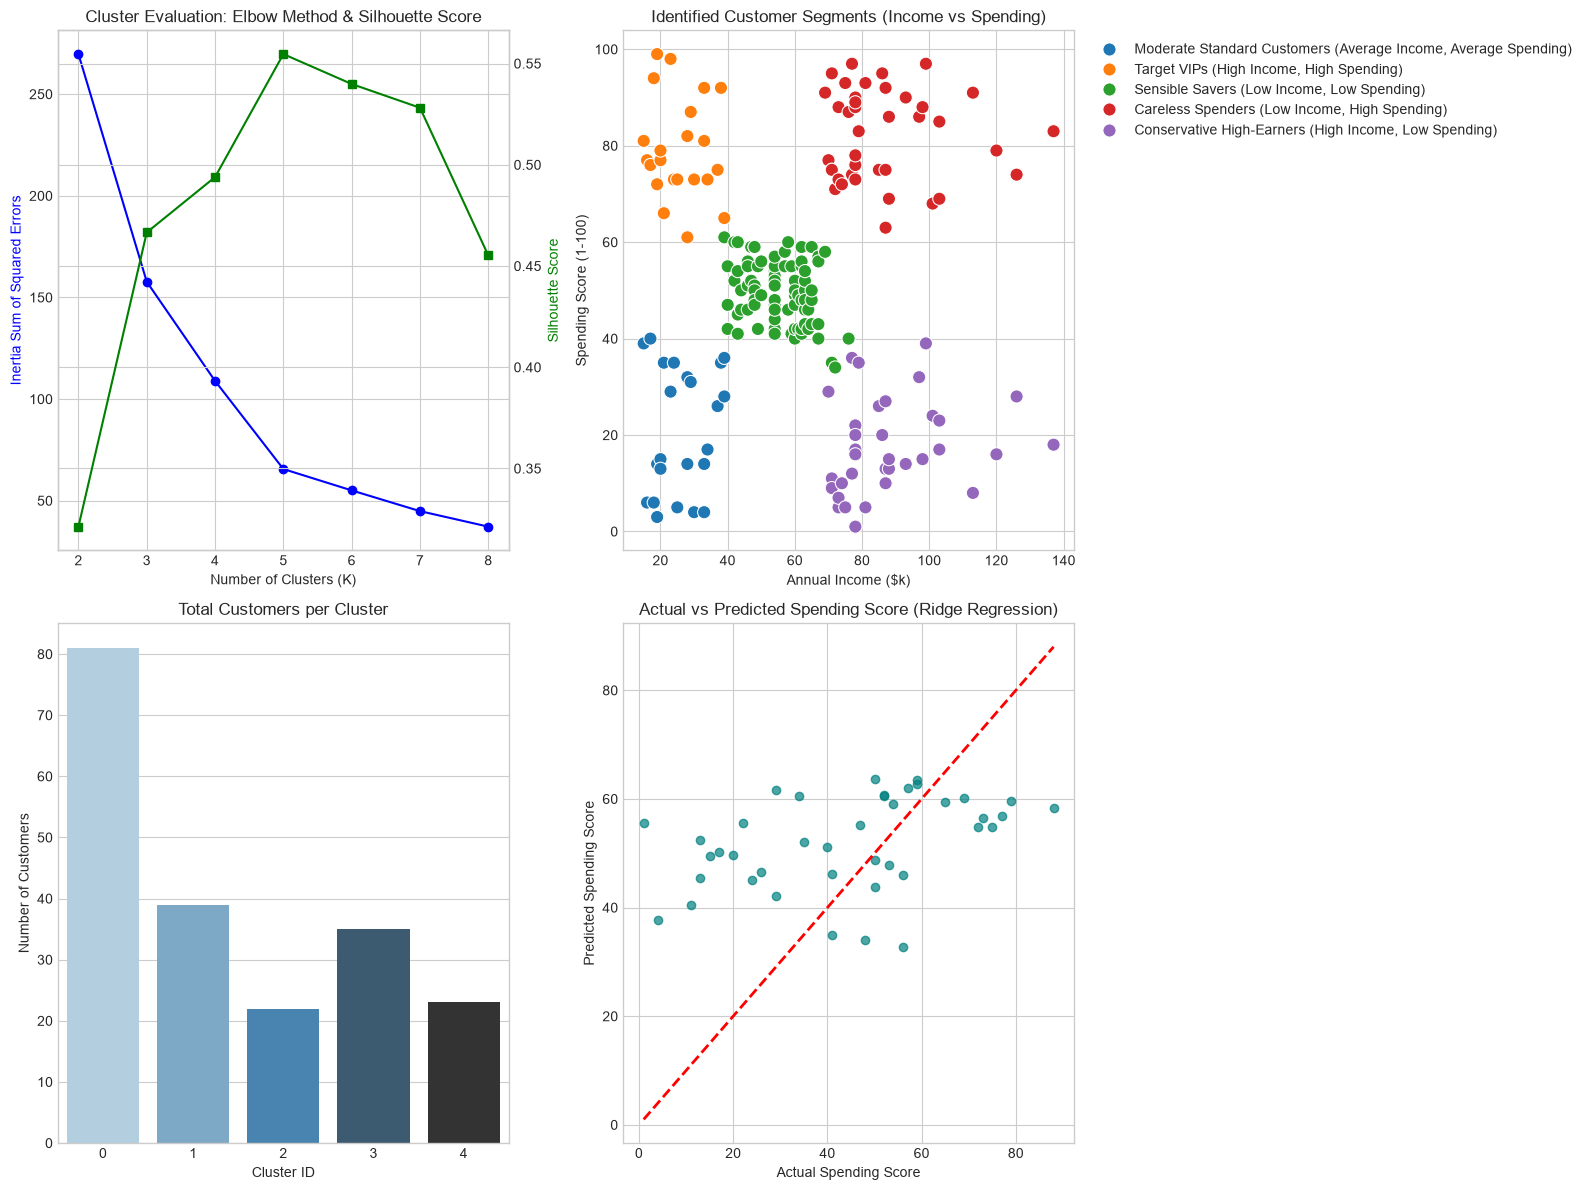

In [2]:
# ==============================================================================
# CUSTOMER SEGMENTATION AND PREDICTIVE MACHINE LEARNING PIPELINE
# File: customer_segmentation.ipynb
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Metrics and Preprocessing Tools
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, r2_score, classification_report, roc_auc_score
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV

# Set standard layout style for charts
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

# ------------------------------------------------------------------------------
# STEP 1: LOAD LOCAL DATASET AND CLEAN COLUMNS
# ------------------------------------------------------------------------------
print("--- Loading Local Customer Dataset ---")

# Reading the local CSV file placed in the current directory
df = pd.read_csv('Mall_Customers.csv')

# Renaming columns for standardized feature handling
df = df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
})

print("Dataset successfully loaded. Preview of first 5 records:")
print(df.head())


# ------------------------------------------------------------------------------
# STEP 2: PREPROCESS DATA AND FEATURE SCALING FOR CLUSTERING
# ------------------------------------------------------------------------------
print("\n--- Preprocessing Features for Clustering ---")

# Selecting core features for customer segmentation
clustering_features = ['AnnualIncome', 'SpendingScore']
X_cluster = df[clustering_features]

# Standardize features (Mean = 0, Standard Deviation = 1)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)


# ------------------------------------------------------------------------------
# STEP 3: HYPERPARAMETER TUNING FOR K-MEANS (ELBOW METHOD & SILHOUETTE SCORE)
# ------------------------------------------------------------------------------
print("\n--- Evaluating Optimal Clusters (K) ---")

inertia_list = []
silhouette_score_list = []
k_range = range(2, 9)

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(X_cluster_scaled)
    
    inertia_list.append(kmeans_model.inertia_)
    current_silhouette = silhouette_score(X_cluster_scaled, kmeans_model.labels_)
    silhouette_score_list.append(current_silhouette)
    
    print(f"Cluster Count (K): {k} | Inertia: {kmeans_model.inertia_:.2f} | Silhouette Score: {current_silhouette:.4f}")

# Fitting the final model with K = 5 (Optimal cluster separation)
optimal_k = 5
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = final_kmeans.fit_predict(X_cluster_scaled)

# Mapping meaningful business names to each customer group
segment_mapping = {
    0: 'Sensible Savers (Low Income, Low Spending)',
    1: 'Careless Spenders (Low Income, High Spending)',
    2: 'Target VIPs (High Income, High Spending)',
    3: 'Conservative High-Earners (High Income, Low Spending)',
    4: 'Moderate Standard Customers (Average Income, Average Spending)'
}
df['Customer_Segment'] = df['Cluster'].map(segment_mapping)


# ------------------------------------------------------------------------------
# STEP 4: REGRESSION MODELING (PREDICTING SPENDING SCORE)
# ------------------------------------------------------------------------------
print("\n--- Training Ridge Regression Model ---")

X_reg = df[['Age', 'AnnualIncome']]
y_reg = df['SpendingScore']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Hyperparameter optimization using GridSearchCV
ridge_hyperparams = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_grid_search = GridSearchCV(Ridge(), ridge_hyperparams, cv=5, scoring='r2')
ridge_grid_search.fit(X_train_r, y_train_r)

best_ridge_model = ridge_grid_search.best_estimator_
y_pred_r = best_ridge_model.predict(X_test_r)

print(f"Optimal Alpha Parameter: {ridge_grid_search.best_params_['alpha']}")
print(f"Regression Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}")
print(f"Regression R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")


# ------------------------------------------------------------------------------
# STEP 5: CLASSIFICATION MODELING (PREDICTING HIGH SPENDING LIKELIHOOD)
# ------------------------------------------------------------------------------
print("\n--- Training Logistic Regression Model ---")

# Binary target: 1 if Spending Score is greater than 50, else 0
df['Is_High_Spender'] = (df['SpendingScore'] > 50).astype(int)

X_clf = df[['Age', 'AnnualIncome', 'Cluster']]
y_clf = df['Is_High_Spender']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Tuning classification regularization parameter
logistic_hyperparams = {'C': [0.01, 0.1, 1.0, 10.0]}
logistic_grid_search = GridSearchCV(LogisticRegression(max_iter=1000), logistic_hyperparams, cv=5, scoring='f1')
logistic_grid_search.fit(X_train_c, y_train_c)

best_logistic_model = logistic_grid_search.best_estimator_
y_pred_c = best_logistic_model.predict(X_test_c)

print(f"Optimal Regularization Parameter (C): {logistic_grid_search.best_params_['C']}")
print(f"Classification ROC-AUC Score: {roc_auc_score(y_test_c, best_logistic_model.predict_proba(X_test_c)[:, 1]):.4f}")
print("\nClassification Evaluation Metrics:")
print(classification_report(y_test_c, y_pred_c))


# ------------------------------------------------------------------------------
# STEP 6: GENERATE VISUALIZATIONS DASHBOARD
# ------------------------------------------------------------------------------
print("\n--- Plotting Performance Dashboards ---")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Cluster Selection Metrics (Elbow Method & Silhouette Scores)
twin_axis = axes[0, 0].twinx()
axes[0, 0].plot(k_range, inertia_list, 'b-o', label='Inertia (Elbow Method)')
twin_axis.plot(k_range, silhouette_score_list, 'g-s', label='Silhouette Score')
axes[0, 0].set_title('Cluster Evaluation: Elbow Method & Silhouette Score', fontsize=12)
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Inertia Sum of Squared Errors', color='b')
twin_axis.set_ylabel('Silhouette Score', color='g')

# Chart 2: Customer Segmentation Scatter Plot
sns.scatterplot(
    data=df, x='AnnualIncome', y='SpendingScore', hue='Customer_Segment',
    palette='tab10', s=90, ax=axes[0, 1]
)
axes[0, 1].set_title('Identified Customer Segments (Income vs Spending)', fontsize=12)
axes[0, 1].set_xlabel('Annual Income ($k)')
axes[0, 1].set_ylabel('Spending Score (1-100)')
axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Chart 3: Cluster Distribution Bar Chart
sns.countplot(data=df, x='Cluster', hue='Cluster', palette='Blues_d', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Total Customers per Cluster', fontsize=12)
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Number of Customers')

# Chart 4: Actual vs Predicted Spending Scores
axes[1, 1].scatter(y_test_r, y_pred_r, color='teal', alpha=0.7)
axes[1, 1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[1, 1].set_title('Actual vs Predicted Spending Score (Ridge Regression)', fontsize=12)
axes[1, 1].set_xlabel('Actual Spending Score')
axes[1, 1].set_ylabel('Predicted Spending Score')

plt.tight_layout()
plt.show()